In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import torch
from matplotlib import pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import pickle

data_name = "alpaca"
with open(f"activations_save/activations_llama_alpaca_rank.pkl", "rb") as f:
    activations = pickle.load(f)

In [4]:
activations.keys()

dict_keys(['layer_0.self_attn_q_proj', 'layer_0.mlp_gate_proj', 'layer_1.self_attn_q_proj', 'layer_1.mlp_gate_proj', 'layer_2.self_attn_q_proj', 'layer_2.mlp_gate_proj', 'layer_3.self_attn_q_proj', 'layer_3.mlp_gate_proj', 'layer_4.self_attn_q_proj', 'layer_4.mlp_gate_proj', 'layer_5.self_attn_q_proj', 'layer_5.mlp_gate_proj', 'layer_6.self_attn_q_proj', 'layer_6.mlp_gate_proj', 'layer_7.self_attn_q_proj', 'layer_7.mlp_gate_proj', 'layer_8.self_attn_q_proj', 'layer_8.mlp_gate_proj', 'layer_9.self_attn_q_proj', 'layer_9.mlp_gate_proj', 'layer_10.self_attn_q_proj', 'layer_10.mlp_gate_proj', 'layer_11.self_attn_q_proj', 'layer_11.mlp_gate_proj', 'layer_12.self_attn_q_proj', 'layer_12.mlp_gate_proj', 'layer_13.self_attn_q_proj', 'layer_13.mlp_gate_proj', 'layer_14.self_attn_q_proj', 'layer_14.mlp_gate_proj', 'layer_15.self_attn_q_proj', 'layer_15.mlp_gate_proj', 'layer_16.self_attn_q_proj', 'layer_16.mlp_gate_proj', 'layer_17.self_attn_q_proj', 'layer_17.mlp_gate_proj', 'layer_18.self_attn

X2d: (4096, 4096) C= 4096
mean: min/max = -2.6850674152374268 2.519090175628662
std : min/max = 0.0004003395442850888 2.9443962574005127
val : min/max = -12.1875 10.8125


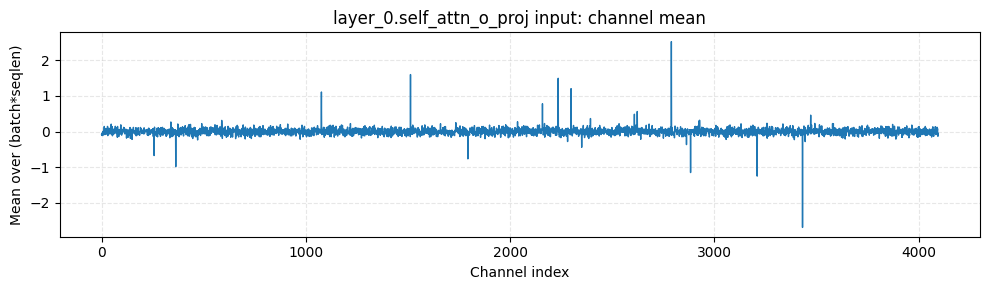

Outliers by zscore (mean): [257, 363, 1076, 1512, 1793, 2158, 2235, 2298, 2622, 2789, 2883, 3209, 3431]
Outliers by MAD    (mean): [257, 363, 1076, 1512, 1793, 2158, 2235, 2298, 2622, 2789, 2883, 3209, 3431]
ch 0257 | mean=-0.671793 std=1.17433 min=-7.0625 max=3.75
ch 0363 | mean=-0.982891 std=1.25311 min=-6.21875 max=1.92969
ch 1076 | mean=1.10832 std=1.37956 min=-4.53125 max=5.90625
ch 1512 | mean=1.59682 std=1.55663 min=-0.792969 max=5.84375
ch 1793 | mean=-0.764757 std=1.47273 min=-8.875 max=2.64062
ch 2158 | mean=0.779905 std=2.14448 min=-6.3125 max=10.5625
ch 2235 | mean=1.49219 std=1.95136 min=-3.03125 max=7.5625
ch 2298 | mean=1.20198 std=1.68086 min=-1.75 max=7.28125
ch 2622 | mean=0.561657 std=0.941737 min=-2.01562 max=5.8125
ch 2789 | mean=2.51909 std=2.9444 min=-3.76562 max=10.8125
ch 2883 | mean=-1.14803 std=1.2816 min=-5.28125 max=0.777344
ch 3209 | mean=-1.24725 std=1.91228 min=-8.1875 max=6.84375
ch 3431 | mean=-2.68507 std=2.82794 min=-12.1875 max=1.28906


In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def channel_stats(x: torch.Tensor):
    """
    x: [..., C]，最后一维视为 channel
    返回：mean/std/min/max（按 channel），以及展平后的 X2d: [N, C]
    """
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x)
    x = x.detach()

    # 展平 batch*seqlen*... -> N
    C = x.shape[-1]
    X2d = x.reshape(-1, C).to(torch.float32)

    mean = X2d.mean(dim=0)
    std  = X2d.std(dim=0, unbiased=False)
    vmin = X2d.min(dim=0).values
    vmax = X2d.max(dim=0).values
    return X2d, mean, std, vmin, vmax

def detect_outlier_channels_by_mean(mean: torch.Tensor, method="zscore", z_th=5.0, mad_th=10.0):
    """
    基于每个 channel 的 mean 来找异常 channel
    - method="zscore": |(mean-mean(mean))/std(mean)| > z_th
    - method="mad":    |(mean-median)/MAD| > mad_th (更稳健)
    返回：outlier_indices (LongTensor), score (Tensor)
    """
    m = mean.to(torch.float32)

    if method == "zscore":
        mu = m.mean()
        sd = m.std(unbiased=False) + 1e-12
        score = (m - mu).abs() / sd
        out = torch.nonzero(score > z_th, as_tuple=False).squeeze(1)
        return out, score

    if method == "mad":
        med = m.median()
        mad = (m - med).abs().median() + 1e-12
        score = (m - med).abs() / mad
        out = torch.nonzero(score > mad_th, as_tuple=False).squeeze(1)
        return out, score

    raise ValueError(f"Unknown method: {method}")

def plot_channel_means(mean: torch.Tensor, title="Channel mean"):
    mean_np = mean.cpu().numpy()
    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(len(mean_np)), mean_np, linewidth=1)
    plt.xlabel("Channel index")
    plt.ylabel("Mean over (batch*seqlen)")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# ====== 用法示例：挑一个你关心的激活张量 ======
x = activations["layer_28.self_attn_q_proj"]["input"][0]  # shape: [B, ..., C]
X2d, mean, std, vmin, vmax = channel_stats(x)

print("X2d:", tuple(X2d.shape), "C=", X2d.shape[1])
print("mean: min/max =", mean.min().item(), mean.max().item())
print("std : min/max =", std.min().item(),  std.max().item())
print("val : min/max =", vmin.min().item(), vmax.max().item())

plot_channel_means(mean, title="layer_0.self_attn_o_proj input: channel mean")

# 异常 channel（两种判别任选）
out_z, score_z = detect_outlier_channels_by_mean(mean, method="zscore", z_th=5.0)
out_m, score_m = detect_outlier_channels_by_mean(mean, method="mad", mad_th=10.0)

print("Outliers by zscore (mean):", out_z.tolist())
print("Outliers by MAD    (mean):", out_m.tolist())

# 进一步：打印异常 channel 的更详细统计
def print_channels_detail(ch_idx):
    for c in ch_idx:
        c = int(c)
        print(f"ch {c:04d} | mean={mean[c].item():.6g} std={std[c].item():.6g} min={vmin[c].item():.6g} max={vmax[c].item():.6g}")

print_channels_detail(out_m[:20])  # 只打印前20个

In [5]:
activations['layer_0.self_attn_q_proj']['input'][0].shape

torch.Size([16, 256, 4096])

In [6]:
def analyze_output_singular_values(layer_name):
    # 一共有32层，把每一层的输出奇异值分布绘制到一张图上，折线图形式
    layer_indices = []
    layer_avg_svs = []
    
    for layer in activations:
        if layer_name not in layer:
            continue
        layer_id = int(layer.split(".")[0].split("_")[1])  # e.g., "layers.0"
        # outputs = activations[layer]["output"]  # list of tensors

        # total_singular_values = 0
        
        # for output in outputs:
        #     tensor = output.reshape(-1, output.shape[-1]).to(torch.float32).to(device)
        #     if not isinstance(tensor, torch.Tensor):
        #         continue
        #     singular_values = torch.linalg.svdvals(tensor)
        #     total_singular_values += singular_values.sum().item()
            
        # avg_singular_value = total_singular_values / len(outputs)
        
        # layer_indices.append(layer_id)
        # layer_avg_svs.append(avg_singular_value)
        
        output = activations[layer]["input"][0]
        tensor = output.reshape(-1, output.shape[-1]).to(torch.float32).to(device)
        # U, S, Vh = torch.linalg.svd(tensor, full_matrices=False)
        singular_values = torch.linalg.svdvals(tensor)
        
        layer_indices.append(layer_id)
        layer_avg_svs.append(singular_values)
        
    return layer_indices, layer_avg_svs


In [7]:
def plot_singular_value_distribution(layer_ids, layer_svs, layer_name):
    plt.figure(figsize=(10, 6))
    
    cmap = plt.cm.get_cmap("viridis", len(layer_ids))
    colors = [cmap(i) for i in range(len(layer_ids))]

    for layer_id, sv, color in zip(layer_ids, layer_svs, colors):
        sv = sv.cpu().numpy()
        x = range(len(sv))            # 奇异值索引
        plt.plot(x, sv, label=f"layer {layer_id}", color=color)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.title(f"Singular value spectra across layers for {layer_name}")
    plt.grid(True)
    
    plt.yscale("log")  # 如果差距太大，用对数坐标更清晰；不想用可以删掉这一行
    # ymin = 1e-3
    max_sv = max(sv.max().item() for sv in layer_svs)
    ymax = 10 ** math.ceil(math.log10(max_sv))
    plt.ylim(top=ymax)

    # 图例放到右侧，避免挡住曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_singular_value_topX_distribution(layer_ids, layer_svs, layer_name, X=10):
    plt.figure(figsize=(10, 6))
    
    cmap = plt.cm.get_cmap("viridis", len(layer_ids))
    colors = [cmap(i) for i in range(len(layer_ids))]

    for layer_id, sv, color in zip(layer_ids, layer_svs, colors):
        sv = sv[:X].cpu().numpy()
        x = range(len(sv))            # 奇异值索引
        plt.plot(x, sv, label=f"layer {layer_id}", color=color)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.title(f"Singular value spectra across layers for {layer_name} top {X}")
    plt.grid(True)
    
    plt.yscale("log")  # 如果差距太大，用对数坐标更清晰；不想用可以删掉这一行
    # ymin = 1e-1
    max_sv = max(sv.max().item() for sv in layer_svs)
    ymax = 10 ** math.ceil(math.log10(max_sv))
    plt.ylim(top=ymax)

    # 图例放到右侧，避免挡住曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [9]:
layer_name = "attn_q_proj"
layer_ids, layer_svs = analyze_output_singular_values(layer_name)

/tmp/ipykernel_1703846/3106386022.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(layer_ids))


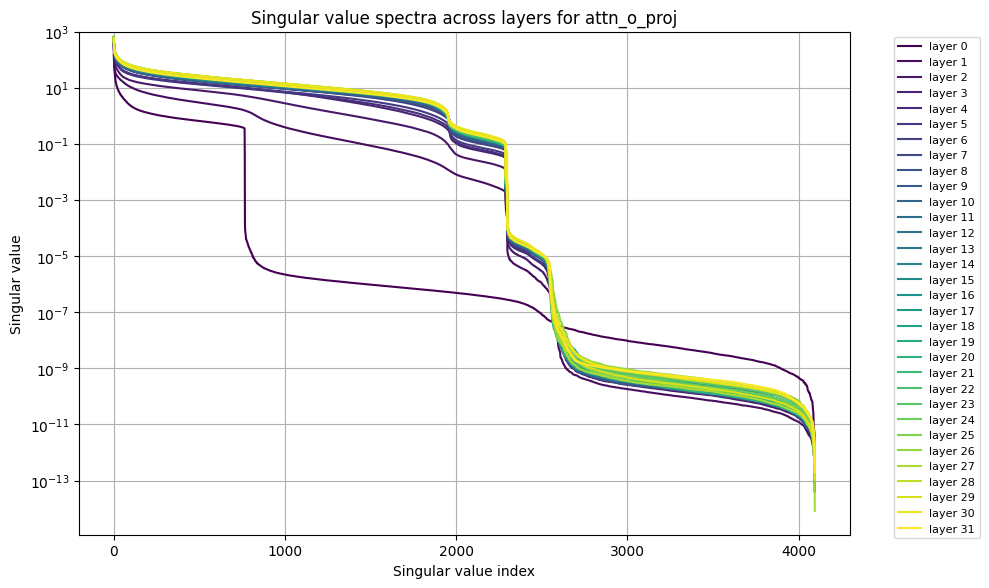

In [10]:
plot_singular_value_distribution(layer_ids, layer_svs, 'attn_o_proj')

/tmp/ipykernel_1703846/3210539342.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(layer_ids))


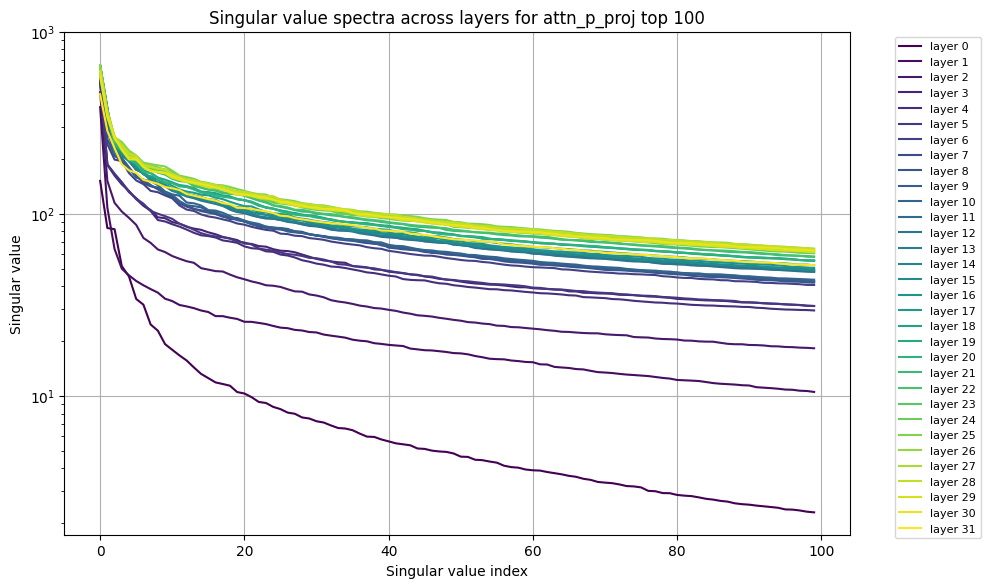

In [11]:
plot_singular_value_topX_distribution(layer_ids, layer_svs, 'attn_p_proj', X=100)

In [12]:
def cache_all_layer_singular_values(layer_name, io_key="input", sample_idx=0):
    sv_dict = {}
    for layer in activations:
        if layer_name not in layer:
            continue
        layer_id = int(layer.split(".")[0].split("_")[1])
        x = activations[layer][io_key][sample_idx]
        X = x.reshape(-1, x.shape[-1]).to(torch.float32).to(device)
        sv = torch.linalg.svdvals(X).cpu()
        sv_dict[layer_id] = sv
    return sv_dict

def analyze_energy_ratio_from_sv_cache(sv_cache, rank_ratio):
    layer_ids, ratios, ks, totals = [], [], [], []
    for layer_id in sorted(sv_cache.keys()):
        sv = sv_cache[layer_id]
        k = max(1, int(math.ceil(len(sv) * rank_ratio)))
        energy = sv.pow(2)
        total = energy.sum()
        topk = energy[:k].sum()
        ratio = (topk / (total + 1e-12)).item()
        layer_ids.append(layer_id)
        ratios.append(ratio)
        ks.append(k)
        totals.append(total.item())
    return layer_ids, ratios, ks, totals

def plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio):
    plt.figure(figsize=(8, 4))
    plt.plot(layer_ids, ratios, marker="o")
    plt.xlabel("Layer id")
    plt.ylabel("Energy captured (sum sigma^2)")
    plt.title(f"{layer_name}: rank_ratio={rank_ratio} energy capture")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [13]:
# 只需SVD一次，缓存所有层的奇异值
layer_name = "mlp_gate_proj"  # 例如："mlp_gate_proj"、"self_attn_q_proj"等
mlp_sv_cache = cache_all_layer_singular_values(layer_name, io_key="input", sample_idx=0)

In [14]:
# 只需SVD一次，缓存所有层的奇异值
layer_name = "self_attn_q_proj"  # 例如："mlp_gate_proj"、"self_attn_q_proj"等
attn_q_proj_sv_cache = cache_all_layer_singular_values(layer_name, io_key="input", sample_idx=0)

layer 00: k=128, energy_ratio=0.7520
layer 01: k=128, energy_ratio=0.6399
layer 02: k=128, energy_ratio=0.5905
layer 03: k=128, energy_ratio=0.5824
layer 04: k=128, energy_ratio=0.6117
layer 05: k=128, energy_ratio=0.6212
layer 06: k=128, energy_ratio=0.6340
layer 07: k=128, energy_ratio=0.6489
layer 08: k=128, energy_ratio=0.6581
layer 09: k=128, energy_ratio=0.6643
layer 10: k=128, energy_ratio=0.6684
layer 11: k=128, energy_ratio=0.6663
layer 12: k=128, energy_ratio=0.6640
layer 13: k=128, energy_ratio=0.6718
layer 14: k=128, energy_ratio=0.6674
layer 15: k=128, energy_ratio=0.6682
layer 16: k=128, energy_ratio=0.6728
layer 17: k=128, energy_ratio=0.6594
layer 18: k=128, energy_ratio=0.6617
layer 19: k=128, energy_ratio=0.6558
layer 20: k=128, energy_ratio=0.6645
layer 21: k=128, energy_ratio=0.6620
layer 22: k=128, energy_ratio=0.6638
layer 23: k=128, energy_ratio=0.6584
layer 24: k=128, energy_ratio=0.6590
layer 25: k=128, energy_ratio=0.6572
layer 26: k=128, energy_ratio=0.6581
l

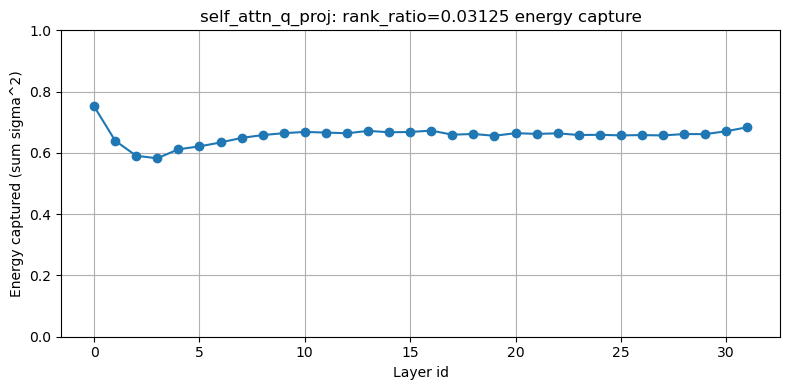

In [32]:
# mlp
rank_ratio = 1 / 32.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(mlp_sv_cache, rank_ratio)

for lid, r, k in zip(layer_ids, ratios, ks):
    print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio)

layer 00: k=256, energy_ratio=0.8474
layer 01: k=256, energy_ratio=0.7718
layer 02: k=256, energy_ratio=0.7319
layer 03: k=256, energy_ratio=0.7215
layer 04: k=256, energy_ratio=0.7429
layer 05: k=256, energy_ratio=0.7504
layer 06: k=256, energy_ratio=0.7597
layer 07: k=256, energy_ratio=0.7713
layer 08: k=256, energy_ratio=0.7784
layer 09: k=256, energy_ratio=0.7825
layer 10: k=256, energy_ratio=0.7861
layer 11: k=256, energy_ratio=0.7843
layer 12: k=256, energy_ratio=0.7834
layer 13: k=256, energy_ratio=0.7890
layer 14: k=256, energy_ratio=0.7862
layer 15: k=256, energy_ratio=0.7866
layer 16: k=256, energy_ratio=0.7898
layer 17: k=256, energy_ratio=0.7807
layer 18: k=256, energy_ratio=0.7825
layer 19: k=256, energy_ratio=0.7779
layer 20: k=256, energy_ratio=0.7838
layer 21: k=256, energy_ratio=0.7825
layer 22: k=256, energy_ratio=0.7845
layer 23: k=256, energy_ratio=0.7805
layer 24: k=256, energy_ratio=0.7805
layer 25: k=256, energy_ratio=0.7786
layer 26: k=256, energy_ratio=0.7790
l

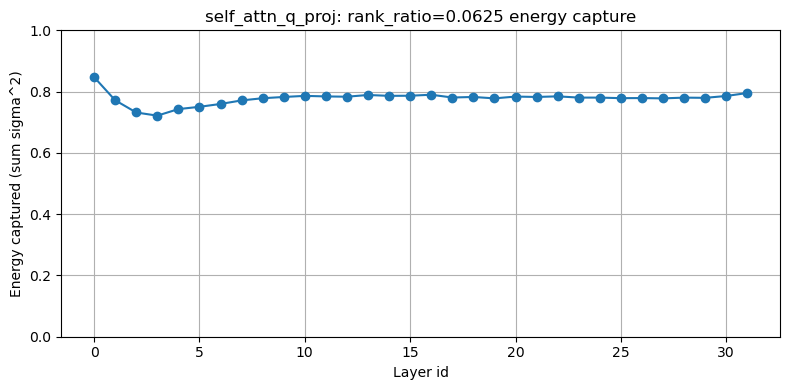

In [33]:
# mlp
rank_ratio = 1 / 16.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(mlp_sv_cache, rank_ratio)

for lid, r, k in zip(layer_ids, ratios, ks):
    print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio)

layer 00: k=512, energy_ratio=0.9470
layer 01: k=512, energy_ratio=0.9077
layer 02: k=512, energy_ratio=0.8791
layer 03: k=512, energy_ratio=0.8668
layer 04: k=512, energy_ratio=0.8749
layer 05: k=512, energy_ratio=0.8774
layer 06: k=512, energy_ratio=0.8809
layer 07: k=512, energy_ratio=0.8868
layer 08: k=512, energy_ratio=0.8905
layer 09: k=512, energy_ratio=0.8922
layer 10: k=512, energy_ratio=0.8945
layer 11: k=512, energy_ratio=0.8931
layer 12: k=512, energy_ratio=0.8929
layer 13: k=512, energy_ratio=0.8958
layer 14: k=512, energy_ratio=0.8948
layer 15: k=512, energy_ratio=0.8950
layer 16: k=512, energy_ratio=0.8971
layer 17: k=512, energy_ratio=0.8927
layer 18: k=512, energy_ratio=0.8941
layer 19: k=512, energy_ratio=0.8918
layer 20: k=512, energy_ratio=0.8950
layer 21: k=512, energy_ratio=0.8947
layer 22: k=512, energy_ratio=0.8960
layer 23: k=512, energy_ratio=0.8938
layer 24: k=512, energy_ratio=0.8936
layer 25: k=512, energy_ratio=0.8923
layer 26: k=512, energy_ratio=0.8924
l

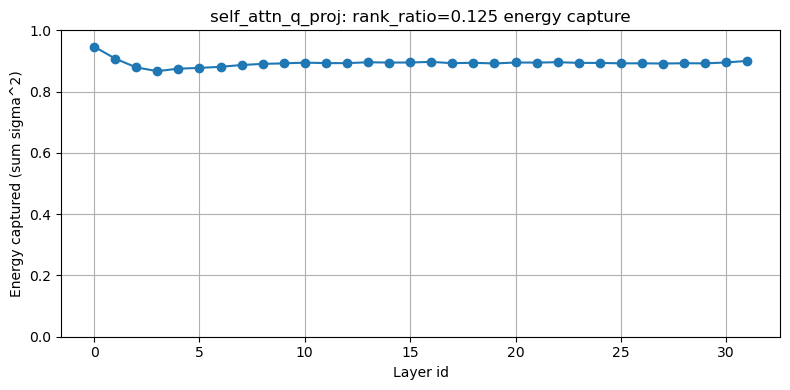

In [34]:
# mlp
rank_ratio = 1 / 8.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(mlp_sv_cache, rank_ratio)

for lid, r, k in zip(layer_ids, ratios, ks):
    print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio)

layer 00: k=128, energy_ratio=0.9903
layer 01: k=128, energy_ratio=0.9485
layer 02: k=128, energy_ratio=0.8565
layer 03: k=128, energy_ratio=0.7658
layer 04: k=128, energy_ratio=0.7786
layer 05: k=128, energy_ratio=0.7665
layer 06: k=128, energy_ratio=0.7490
layer 07: k=128, energy_ratio=0.7537
layer 08: k=128, energy_ratio=0.7715
layer 09: k=128, energy_ratio=0.7637
layer 10: k=128, energy_ratio=0.7669
layer 11: k=128, energy_ratio=0.7574
layer 12: k=128, energy_ratio=0.7573
layer 13: k=128, energy_ratio=0.7399
layer 14: k=128, energy_ratio=0.7506
layer 15: k=128, energy_ratio=0.7510
layer 16: k=128, energy_ratio=0.7388
layer 17: k=128, energy_ratio=0.7300
layer 18: k=128, energy_ratio=0.7167
layer 19: k=128, energy_ratio=0.7146
layer 20: k=128, energy_ratio=0.7067
layer 21: k=128, energy_ratio=0.7138
layer 22: k=128, energy_ratio=0.7180
layer 23: k=128, energy_ratio=0.7083
layer 24: k=128, energy_ratio=0.7129
layer 25: k=128, energy_ratio=0.6984
layer 26: k=128, energy_ratio=0.7034
l

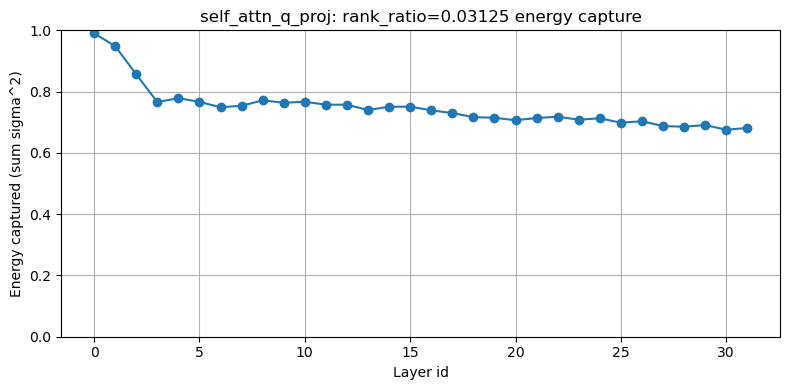

In [35]:
# attn
rank_ratio = 1 / 32.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(attn_q_proj_sv_cache, rank_ratio)

for lid, r, k in zip(layer_ids, ratios, ks):
    print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio)

layer 00: k=256, energy_ratio=0.9951
layer 01: k=256, energy_ratio=0.9751
layer 02: k=256, energy_ratio=0.9109
layer 03: k=256, energy_ratio=0.8461
layer 04: k=256, energy_ratio=0.8538
layer 05: k=256, energy_ratio=0.8461
layer 06: k=256, energy_ratio=0.8355
layer 07: k=256, energy_ratio=0.8403
layer 08: k=256, energy_ratio=0.8526
layer 09: k=256, energy_ratio=0.8474
layer 10: k=256, energy_ratio=0.8491
layer 11: k=256, energy_ratio=0.8438
layer 12: k=256, energy_ratio=0.8436
layer 13: k=256, energy_ratio=0.8320
layer 14: k=256, energy_ratio=0.8399
layer 15: k=256, energy_ratio=0.8402
layer 16: k=256, energy_ratio=0.8314
layer 17: k=256, energy_ratio=0.8267
layer 18: k=256, energy_ratio=0.8177
layer 19: k=256, energy_ratio=0.8164
layer 20: k=256, energy_ratio=0.8108
layer 21: k=256, energy_ratio=0.8164
layer 22: k=256, energy_ratio=0.8190
layer 23: k=256, energy_ratio=0.8132
layer 24: k=256, energy_ratio=0.8155
layer 25: k=256, energy_ratio=0.8055
layer 26: k=256, energy_ratio=0.8081
l

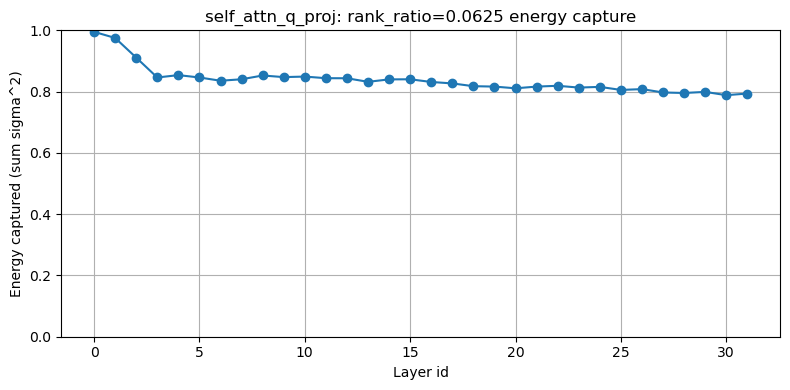

In [37]:
# attn
rank_ratio = 1 / 16.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(attn_q_proj_sv_cache, rank_ratio)

for lid, r, k in zip(layer_ids, ratios, ks):
    print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio)

layer 00: k=512, energy_ratio=0.9986
layer 01: k=512, energy_ratio=0.9932
layer 02: k=512, energy_ratio=0.9644
layer 03: k=512, energy_ratio=0.9283
layer 04: k=512, energy_ratio=0.9296
layer 05: k=512, energy_ratio=0.9244
layer 06: k=512, energy_ratio=0.9190
layer 07: k=512, energy_ratio=0.9215
layer 08: k=512, energy_ratio=0.9276
layer 09: k=512, energy_ratio=0.9247
layer 10: k=512, energy_ratio=0.9252
layer 11: k=512, energy_ratio=0.9232
layer 12: k=512, energy_ratio=0.9228
layer 13: k=512, energy_ratio=0.9169
layer 14: k=512, energy_ratio=0.9214
layer 15: k=512, energy_ratio=0.9216
layer 16: k=512, energy_ratio=0.9171
layer 17: k=512, energy_ratio=0.9155
layer 18: k=512, energy_ratio=0.9111
layer 19: k=512, energy_ratio=0.9109
layer 20: k=512, energy_ratio=0.9081
layer 21: k=512, energy_ratio=0.9112
layer 22: k=512, energy_ratio=0.9124
layer 23: k=512, energy_ratio=0.9098
layer 24: k=512, energy_ratio=0.9105
layer 25: k=512, energy_ratio=0.9054
layer 26: k=512, energy_ratio=0.9062
l

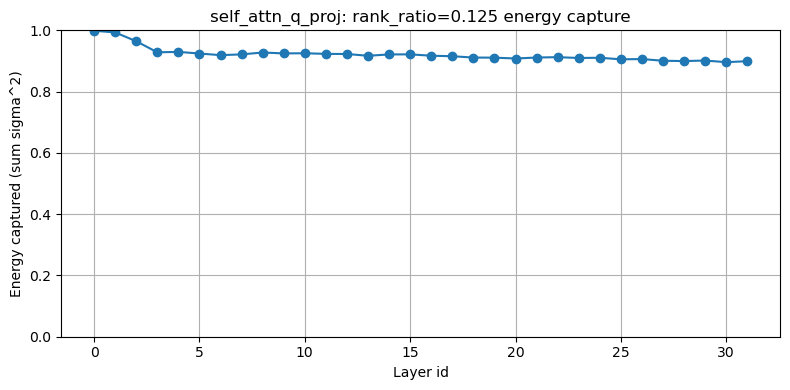

In [38]:
# attn
rank_ratio = 1 / 8.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(attn_q_proj_sv_cache, rank_ratio)

for lid, r, k in zip(layer_ids, ratios, ks):
    print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio)

[0.752007007598877, 0.6398619413375854, 0.5905477404594421, 0.5823756456375122, 0.6117283701896667, 0.6211874485015869, 0.6339801549911499, 0.6489323973655701, 0.6581016182899475, 0.6643196940422058, 0.6684362292289734, 0.6663333177566528, 0.6639862656593323, 0.6718379259109497, 0.6673561334609985, 0.6682205200195312, 0.6727504730224609, 0.6594275832176208, 0.6617161631584167, 0.6558442115783691, 0.6644545793533325, 0.6620278358459473, 0.6638387441635132, 0.6583924293518066, 0.6589969396591187, 0.6571747660636902, 0.6581162810325623, 0.6569768190383911, 0.6614827513694763, 0.6612065434455872, 0.6706798672676086, 0.6837425827980042]
[0.8473973870277405, 0.7718077301979065, 0.731872022151947, 0.7215389609336853, 0.742920458316803, 0.7503666281700134, 0.7597097754478455, 0.7712660431861877, 0.7784109711647034, 0.7824804782867432, 0.7861006855964661, 0.7843210697174072, 0.7833791971206665, 0.7889767289161682, 0.7861584424972534, 0.7865664958953857, 0.7898073196411133, 0.7807161808013916, 0

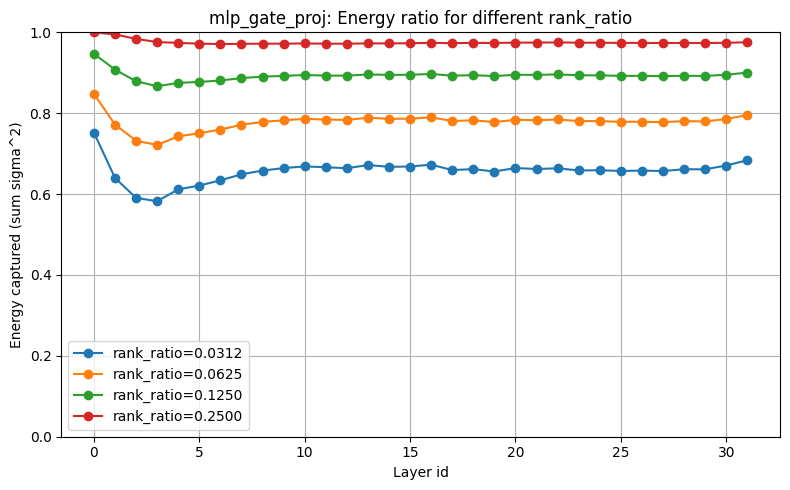

In [15]:
# 假设你已经有 mlp_sv_cache 或 attn_q_proj_sv_cache

def plot_multi_rank_energy_ratios(sv_cache, layer_name, rank_ratios, legend_loc="best"):
    plt.figure(figsize=(8, 5))
    for rr in rank_ratios:
        layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(sv_cache, rr)
        print(ratios)
        plt.plot(layer_ids, ratios, marker="o", label=f"rank_ratio={rr:.4f}")
    plt.xlabel("Layer id")
    plt.ylabel("Energy captured (sum sigma^2)")
    plt.title(f"{layer_name}: Energy ratio for different rank_ratio")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.show()

# 示例用法
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_multi_rank_energy_ratios(mlp_sv_cache, "mlp_gate_proj", rank_ratios)

[0.9902970194816589, 0.948504626750946, 0.8564514517784119, 0.7658106684684753, 0.7785583734512329, 0.7665435075759888, 0.7490007281303406, 0.753740668296814, 0.7714539766311646, 0.763677179813385, 0.7668682336807251, 0.7574045062065125, 0.75726318359375, 0.7399031519889832, 0.7506055235862732, 0.7509866952896118, 0.7388463020324707, 0.7300150394439697, 0.7167431712150574, 0.7146151661872864, 0.7066913843154907, 0.7137923836708069, 0.7180228233337402, 0.7083129286766052, 0.7129172682762146, 0.6984283924102783, 0.7033994197845459, 0.6874227523803711, 0.6853541731834412, 0.6909565925598145, 0.6754578351974487, 0.6815478205680847]
[0.9950798749923706, 0.9751149415969849, 0.9109316468238831, 0.8460944890975952, 0.8538494110107422, 0.8460875153541565, 0.8355187773704529, 0.840272843837738, 0.8526038527488708, 0.8473508358001709, 0.849064290523529, 0.8438121676445007, 0.8435710072517395, 0.8319585919380188, 0.8398783206939697, 0.8402413725852966, 0.8314394950866699, 0.8267289996147156, 0.817

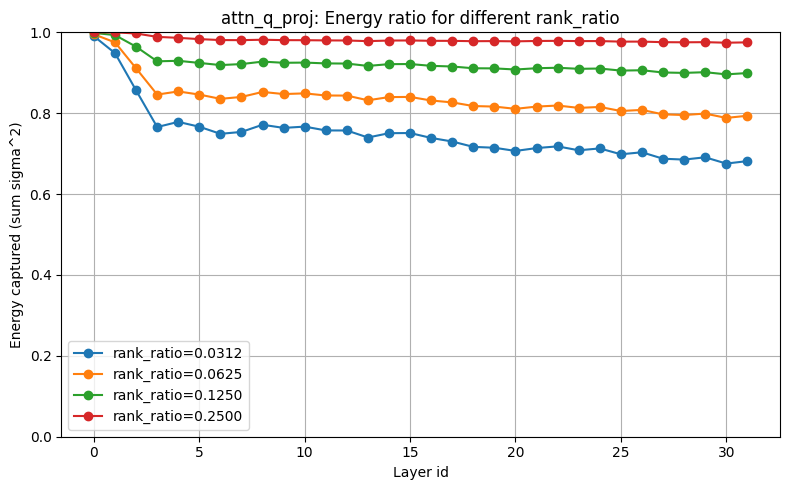

In [16]:
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_multi_rank_energy_ratios(attn_q_proj_sv_cache, "attn_q_proj", rank_ratios)

A = L1 @ L2 + R

探讨一下R的数值分布规律

In [52]:
from meft.linalg.qb import randomized_qb

In [90]:
tensor = activations['layer_31.self_attn_o_proj']["output"][1].reshape(-1, activations['layer_31.self_attn_o_proj']["output"][0].shape[-1]).to(torch.float32).to(device)
print(tensor.shape)

Q, B = randomized_qb(tensor, rank=128)

torch.Size([4096, 4096])


In [91]:
Q.shape, B.shape

(torch.Size([4096, 128]), torch.Size([128, 4096]))

In [92]:
R = tensor - Q @ B
R.shape
R

tensor([[ 2.4970e-04,  2.9306e-04,  2.8341e-04,  ..., -3.3833e-05,
         -2.0097e-06, -8.5430e-05],
        [ 4.6072e-04, -8.3854e-04, -2.2056e-03,  ..., -4.6200e-03,
         -4.6505e-04,  2.1763e-03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-4.6204e-02, -6.0493e-02, -1.5183e-01,  ...,  9.0014e-02,
         -1.0916e-01, -2.1212e-01],
        [-4.8413e-02, -1.0495e-01, -1.8770e-01,  ...,  1.0973e-01,
         -1.2133e-01, -1.9574e-01],
        [ 1.2001e-01,  1.4406e-01, -1.9689e-01,  ...,  1.3895e-01,
          1.0340e-01, -5.6066e-02]], device='cuda:0')

In [93]:
R.max(), R.min(), R.mean(), R.std()

(tensor(2.3016, device='cuda:0'),
 tensor(-1.4793, device='cuda:0'),
 tensor(-5.3313e-06, device='cuda:0'),
 tensor(0.1007, device='cuda:0'))

In [100]:
torch.sum(R.abs() > 1e-2)

tensor(11264643, device='cuda:0')

R stats: min = -1.4792678 max = 2.3015776 mean = -5.331304e-06


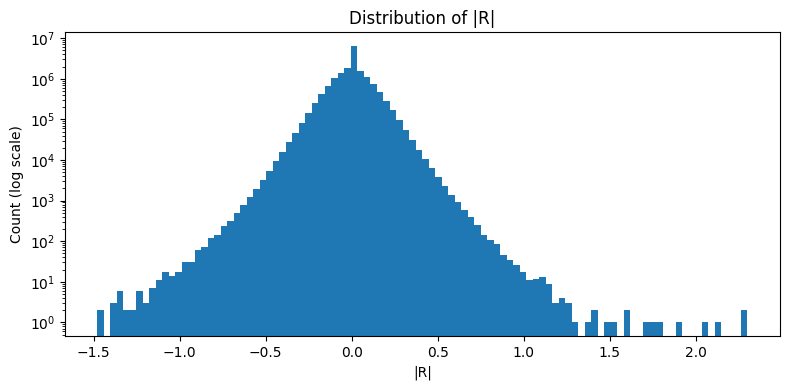

In [99]:
import numpy as np

R_flat = R.detach().reshape(-1).cpu().numpy()  # 取绝对值再拉平

print("R stats:",
      "min =", R_flat.min(),
      "max =", R_flat.max(),
      "mean =", R_flat.mean())

plt.figure(figsize=(8, 4))
plt.hist(R_flat, bins=100, log=True)   # y 轴用 log，看尾部更清楚
# plt.hist(R_flat, bins=100, log=False)
plt.xlabel("|R|")
plt.ylabel("Count (log scale)")
plt.title("Distribution of |R|")
plt.tight_layout()
plt.show()

In [ ]:
import bitsandbytes as bnb

quant_state = bnb.functional.quantize_4bit(
    R,
    quant_type="nf4",  # 指定 NF4 格式（适配正态分布的 R）
    blocksize=128,      # 分块量化，平衡精度/速度
    # blocksize=R.shape[-1],  # 不分块
    compress_statistics=True
)

R_nf4_dequant = bnb.functional.dequantize_4bit(*quant_state)

mse = torch.mean((R - R_nf4_dequant)**2)
print(f"NF4 量化 MSE: {mse.item()}")

NF4 量化 MSE: 9.689359285403043e-05


In [121]:
R

tensor([[ 2.4970e-04,  2.9306e-04,  2.8341e-04,  ..., -3.3833e-05,
         -2.0097e-06, -8.5430e-05],
        [ 4.6072e-04, -8.3854e-04, -2.2056e-03,  ..., -4.6200e-03,
         -4.6505e-04,  2.1763e-03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-4.6204e-02, -6.0493e-02, -1.5183e-01,  ...,  9.0014e-02,
         -1.0916e-01, -2.1212e-01],
        [-4.8413e-02, -1.0495e-01, -1.8770e-01,  ...,  1.0973e-01,
         -1.2133e-01, -1.9574e-01],
        [ 1.2001e-01,  1.4406e-01, -1.9689e-01,  ...,  1.3895e-01,
          1.0340e-01, -5.6066e-02]], device='cuda:0')

In [122]:
R_nf4_dequant

tensor([[ 4.1568e-04,  5.7074e-04,  4.1568e-04,  ...,  0.0000e+00,
          0.0000e+00, -1.5378e-04],
        [ 9.4088e-04, -1.0765e-03, -2.1846e-03,  ..., -4.4342e-03,
         -7.6892e-04,  2.0784e-03],
        [-1.6890e-03, -1.6890e-03, -1.6890e-03,  ..., -1.6890e-03,
         -1.6890e-03, -1.6890e-03],
        ...,
        [-3.8637e-02, -7.8408e-02, -1.6758e-01,  ...,  8.0057e-02,
         -9.2525e-02, -2.2646e-01],
        [-4.2395e-02, -8.6035e-02, -1.8388e-01,  ...,  1.1131e-01,
         -1.3009e-01, -1.7297e-01],
        [ 1.2387e-01,  1.6155e-01, -1.9247e-01,  ...,  1.4881e-01,
          1.1410e-01, -6.2392e-02]], device='cuda:0')

In [123]:
type(quant_state)

tuple

In [124]:
len(quant_state[0])

8388608

In [126]:
quant_state[0].dtype

torch.uint8

In [125]:
quant_state[1]